In [13]:
# import libraries needed
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [15]:
# define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
# split data into train and val data
BATCH_SIZE = 128

# data transform to go from photo -> tensor
data_transform = transforms.Compose([transforms.ToTensor()])

# train dataset & train dataloader
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=data_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [17]:
# Autoencoder class
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 32, hidden_dim = 256):
    super().__init__() # That last line is important because it initializes PyTorch's internal bookkeeping.

    # Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )

    # Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid() # sigmoid so we turn it back into 0-1 grayscale pixel values
    )

  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon


In [18]:
# define model & loss
model = AutoEncoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
# Model Training
epochs = 5

model.train() # activates things like dropout, etc
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader: # train loader works batch-wise gives (128, 1, 28, 28) -> 128 images in the batch, 1 grayscale channel, 28 pixels high and wide
                            # where x is one batch, so (128, 1, 28, 28). trainloader gives all 1000 batches or wtv in the dataset though

    x = x.view(-1, 784).to(device) # you put -1 because batch might not always be 128, ie. the last batch could have 125 images instead
    # (125,1,28,28) -> (125,784) for ex

    optimizer.zero_grad() # for each batch, zero out the grad first -> doing batch-wise gradients
    x_recon = model(x)
    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader) #len(train_loder) gives us # batches
  # so, remember an epoch goes through all batches from the dataset
  print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [1/5], Loss: 0.043787
Epoch [2/5], Loss: 0.018630
Epoch [3/5], Loss: 0.014727
Epoch [4/5], Loss: 0.013172
Epoch [5/5], Loss: 0.012283


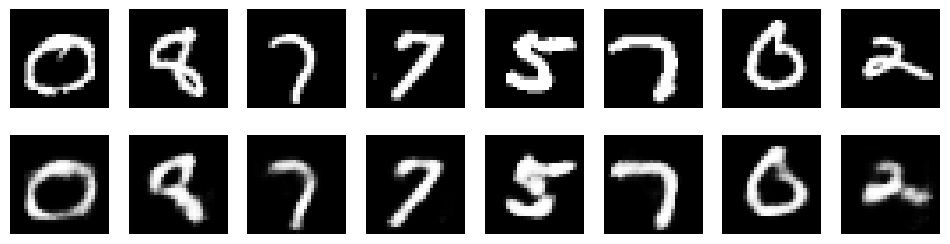

In [21]:
model.eval()

with torch.no_grad():
    # Grab one batch from the DataLoader
    x, _ = next(iter(train_loader))

    # [128, 1, 28, 28] -> [128, 784]
    x = x.view(-1, 784).to(device)

    # Run through autoencoder
    x_recon = model(x)

    n = 8
    plt.figure(figsize=(12, 3))

    for i in range(n):
        # Top row: original images
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")

        # Bottom row: reconstructed images
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recon[i].view(28, 28).cpu(), cmap="gray")
        plt.axis("off")

    plt.show()